In [1]:
import os
import re
import cv2
import numpy as np
import pandas as pd

from PIL import Image
from typhoon_ocr import ocr_document

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [2]:
import os

# Load API key from environment variable (never hardcode secrets in notebooks)
API_KEY = os.environ.get("TYPHOON_API_KEY", "")
if not API_KEY:
    raise ValueError("Please set the TYPHOON_API_KEY environment variable")

In [3]:
def normalize(text):
    return re.sub(r"\s+", " ", text.lower())

In [4]:
MONTHS = (
    "jan|january|feb|february|mar|march|apr|april|may|"
    "jun|june|jul|july|aug|august|sep|september|"
    "oct|october|nov|november|dec|december"
)

def detect_date(text):
    t = normalize(text)
    patterns = [
        r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
        rf"\b\d{{1,2}}\s+({MONTHS})\s+\d{{4}}\b",
        rf"\b({MONTHS})\s+\d{{1,2}},?\s+\d{{4}}\b"
    ]
    return int(any(re.search(p, t) for p in patterns))

In [5]:
def detect_store_name(text):
    keywords = ["co.", "ltd", "shop", "store", "hotel", "company"]
    lines = text.lower().split("\n")
    return int(any(any(k in line for k in keywords) for line in lines))

In [6]:
def detect_store_address(text):
    address_keywords = ["road", "rd", "street", "soi", "district", "chiang rai", "bangkok"]
    lines = text.lower().split("\n")
    return int(any(any(k in line for k in address_keywords) and re.search(r"\d+", line) for line in lines))

In [7]:
def detect_store_tax_id(text):
    MFU_TAX_ID = "0994000165178"
    # Look for explicit tax id label
    matches = re.findall(r'tax\s*id[:\s]+([\d\-]{10,})', text, re.IGNORECASE)
    for m in matches:
        clean = re.sub(r'[\-\s]', '', m)
        if clean != MFU_TAX_ID and len(clean) >= 10:
            return 1
    # Fallback: any 13-digit number that is not MFU's
    all_ids = re.findall(r'\b\d{13}\b', text)
    for tid in all_ids:
        if tid != MFU_TAX_ID:
            return 1
    return 0

In [8]:
def detect_amount_in_words(text):
    t = text.lower()
    return int("baht only" in t or "amount in words" in t or "satang" in t)

In [9]:
def detect_signature(text):
    keywords = ["signature", "signed by", "approved by", "received by"]
    t = text.lower()
    return int(any(k in t for k in keywords))

In [10]:
def detect_amount(text):
    # Match grand total or total with currency amount
    if re.search(r'grand\s*total[:\s]*[\d,]+\.\d{2}', text, re.IGNORECASE):
        return 1
    # Match total (not subtotal) followed by a number
    matches = re.finditer(r'(?<!sub)(?<!partial\s)total[:\s\*]*([\d,]+\.\d{2})', text, re.IGNORECASE)
    for m in matches:
        return 1
    return 0

In [11]:
def detect_mfu_name(text):
    return int("mae fah luang university" in text.lower())

In [12]:
def detect_mfu_address(text):
    keywords = ["333 moo 1", "thasud", "muang", "chiang rai", "57100"]
    t = text.lower()
    return int(any(k in t for k in keywords))

In [13]:
def detect_mfu_tax_id(text):
    return int("0994000165178" in text)

In [14]:
# ground_truth.csv must have these columns:
# filename, has_store_name, has_store_address, has_store_tax_id,
# has_date, has_amount, has_amount_words, has_signature,
# has_mfu_name, has_mfu_address, has_mfu_tax_id, label
gt = pd.read_csv("ground_truth.csv")

In [15]:
def build_dataset(folder, gt_df):
    rows = []

    for img in os.listdir(folder):
        if not img.lower().endswith((".jpg", ".png", ".jpeg")):
            continue

        path = os.path.join(folder, img)
        print(f"Processing: {img}")

        text = extract_text(path)

        # Get ground truth row
        gt_row = gt_df[gt_df["filename"] == img]

        if gt_row.empty:
            print(f"Warning: {img} not found in ground truth")
            continue

        # Document label = complete if all fields are 1
        label = 1 if all(gt_row.iloc[0].drop("filename") == 1) else 0

        rows.append({
            # --- Vendor (3 fields) ---
            "has_store_name":    detect_store_name(text),
            "has_store_address": detect_store_address(text),
            "has_store_tax_id":  detect_store_tax_id(text),
            # --- Transaction (4 fields) ---
            "has_date":          detect_date(text),
            "has_amount":        detect_amount(text),
            "has_amount_words":  detect_amount_in_words(text),
            "has_signature":     detect_signature(text),
            # --- Billed To MFU (3 fields) ---
            "has_mfu_name":      detect_mfu_name(text),
            "has_mfu_address":   detect_mfu_address(text),
            "has_mfu_tax_id":    detect_mfu_tax_id(text),
            "label": label
        })

    return rows

In [16]:
import time
from openai import RateLimitError

def extract_text(image_path):
    while True:
        try:
            text = ocr_document(image_path, api_key=API_KEY)
            time.sleep(3)   # add delay between requests
            return text
        except RateLimitError:
            print("Rate limit hit. Waiting 15 seconds...")
            time.sleep(15)

In [17]:
df = pd.DataFrame(build_dataset("data", gt))

print("\nDataset Preview:")
print(df.head())

X = df.drop("label", axis=1)
y = df["label"]

print("\nDataset shape:", X.shape)
print("Label distribution:\n", y.value_counts())

Processing: C1.jpg
Processing: C10.jpg
Processing: C2.jpg
Processing: C3.jpg
Processing: C4.jpg
Processing: C5.jpg
Processing: C6.jpg
Processing: C7.jpg
Processing: C8.jpg
Processing: C9.jpg
Processing: U1.jpg
Processing: U10.jpg
Processing: U2.jpg
Processing: U3.jpg
Processing: U4.jpg
Processing: U5.jpg
Processing: U6.jpg
Processing: U7.jpg
Processing: U8.jpg
Processing: U9.jpg

Dataset Preview:
   has_store_name  has_store_address  has_store_tax_id  has_date  has_amount  \
0               1                  1                 1         1           1   
1               0                  1                 1         1           1   
2               1                  1                 1         1           1   
3               0                  1                 1         1           1   
4               1                  1                 1         1           1   

   has_amount_words  has_signature  has_mfu_name  has_mfu_address  \
0                 1              0             1  

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Linear SVM": SVC(kernel="linear", probability=True)
}

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Cross-validated predictions
    y_pred = cross_val_predict(model, X, y, cv=cv)
    y_prob = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]

    results[name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    print("Accuracy :", accuracy_score(y, y_pred))
    print("Precision:", precision_score(y, y_pred))
    print("Recall   :", recall_score(y, y_pred))
    print("F1 Score :", f1_score(y, y_pred))


Training Logistic Regression...
Accuracy : 0.8
Precision: 0.7272727272727273
Recall   : 0.8888888888888888
F1 Score : 0.8

Training Decision Tree...
Accuracy : 0.9
Precision: 0.8181818181818182
Recall   : 1.0
F1 Score : 0.9

Training Linear SVM...
Accuracy : 0.85
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571


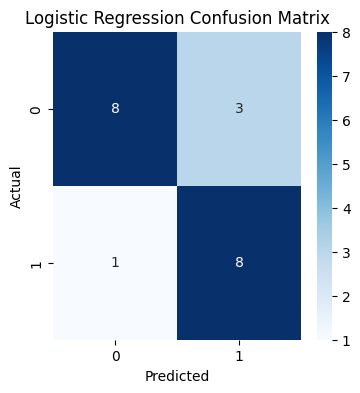

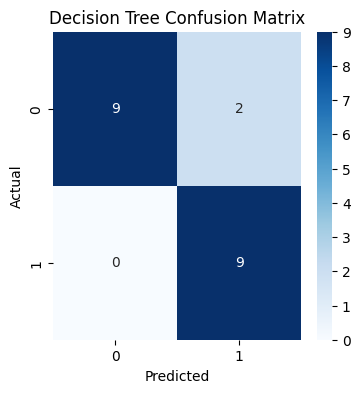

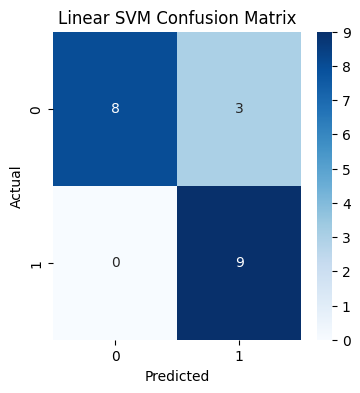

In [21]:
for name in models.keys():
    cm = confusion_matrix(y, results[name]["y_pred"])

    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

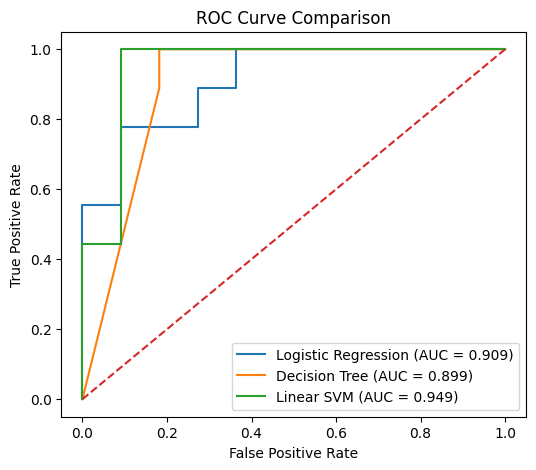

In [22]:
plt.figure(figsize=(6,5))

for name in models.keys():
    y_prob = results[name]["y_prob"]
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [23]:
# Train final model on all data using best model (Linear SVM)
model = SVC(kernel='linear', probability=True)
model.fit(X, y)

import pickle
with open("svm_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [24]:
print(X.shape)

(20, 10)
